# โจทย์ที่ 3: การพยากรณ์รังสีแสงอาทิตย์ด้วย Feature Engineering และ Temporal CNN

## Overview

ได้รับข้อมูลสภาพอากาศและรังสีแสงอาทิตย์รายชั่วโมงของกรุงเทพฯ จาก NASA POWER ให้พยากรณ์ค่า Global Horizontal Irradiance หรือ `ALLSKY_SFC_SW_DWN` ของชั่วโมงถัดไป

โจทย์นี้ต้องสร้าง feature ที่สะท้อนคาบเวลา ตำแหน่งดวงอาทิตย์ สภาพอากาศ ความต่อเนื่องของรังสี และการเปลี่ยนแปลงระยะสั้น ก่อนส่งลำดับย้อนหลัง 48 ชั่วโมงเข้า Temporal CNN ที่สร้างด้วย PyTorch

## Description

ข้อมูลถูกแบ่งตามเวลาเพื่อจำลองการพยากรณ์อนาคตจริง การแบ่งแบบสุ่มหรือ stratified split ไม่เหมาะกับโจทย์นี้ เพราะอาจทำให้ข้อมูลอนาคตรั่วเข้า train การเติม missing value, scaler, lag และ rolling statistics ต้องรักษาทิศทางของเวลา

- `train.csv`: target time ปี 2019-2022 จำนวน 34,895 แถว พร้อม `target`
- `validation.csv`: target time ปี 2023 จำนวน 8,760 แถว พร้อม `target`
- `test.csv`: target time ปี 2024 จำนวน 8,784 แถว ไม่มี `target`

ทุกไฟล์มี timestamp, target time และ feature ชนิดเดียวกัน ชุด test ไม่มีค่าเป้าหมาย แต่สามารถต่อข้อมูลส่วนท้ายของ validation เข้ากับต้น test เพื่อสร้าง lookback 48 ชั่วโมงได้โดยไม่ใช้ข้อมูลอนาคต

กลุ่ม feature ประกอบด้วยค่าจาก NASA POWER, cyclic time features, solar geometry, wind components, clearness index, lag 1/2/3/24/48/168 ชั่วโมง, rolling mean และ standard deviation รวมถึง GHI ramp

## Public Data

โครงสร้างไฟล์ใน `data/public`:

```text
train.csv
validation.csv
test.csv
```

`train.csv` และ `validation.csv` มีคอลัมน์ `target` ส่วน `test.csv` ไม่มีคอลัมน์ดังกล่าว ทั้งสามไฟล์เรียงตามเวลาและต้องไม่ถูกสุ่มสลับก่อนสร้าง sequence

## Evaluation

ใช้ MAE, RMSE และ R-squared โดยรายงานทั้งทุกช่วงเวลาและเฉพาะช่วงที่ค่ารังสีจริงมากกว่า 20

```text
MAE = mean(abs(y_true - y_pred))
RMSE = sqrt(mean((y_true - y_pred)^2))
```

validation ใช้สำหรับเลือก feature, lookback, dilation, dropout, learning rate และ checkpoint ส่วนคำตอบ test ไม่ปรากฏในไฟล์ข้อมูลสาธารณะ

## Submission File

ส่งไฟล์ `submission_solar.csv` จำนวน 8,784 แถว

```csv
id,predicted_ghi
0,0.0
1,0.0
2,5.7
```

- `id`: ลำดับแถวของ `test.csv`
- `predicted_ghi`: ค่า GHI ของชั่วโมงถัดไปที่โมเดลทำนาย และต้องไม่ติดลบ


In [1]:
import math, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, min(8, torch.get_num_threads())))

print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.14.0+cpu


In [2]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
solar_file = data_dir / "nasa_power_bangkok_2019_2024.csv"
parameters = "ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,T2M,T2MDEW,RH2M,PS,WS10M,WD10M,PRECTOTCORR,CLOUD_AMT"

if not solar_file.exists():
    frames = []
    for year in range(2019, 2025):
        url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
        params = {"parameters": parameters, "community": "RE", "longitude": 100.5018, "latitude": 13.7563, "start": f"{year}0101", "end": f"{year}1231", "format": "JSON", "time-standard": "LST"}
        response = requests.get(url, params=params, timeout=180)
        response.raise_for_status()
        values = response.json()["properties"]["parameter"]
        frame = pd.DataFrame(values)
        frame.index = pd.to_datetime(frame.index, format="%Y%m%d%H")
        frames.append(frame)
        print(year, frame.shape)
    pd.concat(frames).sort_index().to_csv(solar_file, index_label="time")

raw = pd.read_csv(solar_file, parse_dates=["time"]).set_index("time").sort_index()
raw = raw.mask(raw <= -900)
raw["PRECTOTCORR"] = raw["PRECTOTCORR"].clip(lower=0).fillna(0)

print("shape:", raw.shape)
print("range:", raw.index.min(), raw.index.max())
raw.head()

shape: (52608, 10)
range: 2019-01-01 00:00:00 2024-12-31 23:00:00


,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,T2M,T2MDEW,RH2M,PS,WS10M,WD10M,PRECTOTCORR,CLOUD_AMT
time,,,,,,,,,,
2019-01-01 00:00:00,0.0,0.0,20.69,14.38,67.25,101.63,4.50,38.5,0.0,20.87
2019-01-01 01:00:00,0.0,0.0,19.76,14.21,70.30,101.59,3.85,37.4,0.0,44.00
2019-01-01 02:00:00,0.0,0.0,19.19,14.02,71.94,101.56,3.68,38.1,0.0,19.92
2019-01-01 03:00:00,0.0,0.0,18.86,13.72,72.02,101.55,3.70,41.7,0.0,58.02
2019-01-01 04:00:00,0.0,0.0,18.32,13.79,74.83,101.59,3.08,38.4,0.0,73.53


,count,mean,std,min,25%,50%,75%,max
ALLSKY_SFC_SW_DWN,52608.0,218.862,293.520,0.00,0.00,8.295,441.70,1010.70
CLRSKY_SFC_SW_DWN,52608.0,264.636,340.010,0.00,0.00,10.750,588.24,1012.92
T2M,52608.0,28.242,4.175,13.09,25.59,27.670,30.74,44.43
T2MDEW,52608.0,22.597,3.167,4.87,21.03,23.750,24.86,27.52
RH2M,52608.0,74.574,18.867,13.58,63.04,79.260,90.71,100.00
PS,52608.0,100.845,0.306,99.76,100.62,100.820,101.05,102.00
WS10M,52608.0,2.829,1.249,0.04,1.96,2.640,3.56,10.10
WD10M,52608.0,168.015,84.873,0.00,77.80,188.600,231.20,359.80
PRECTOTCORR,52608.0,0.000,0.000,0.00,0.00,0.000,0.00,0.00
CLOUD_AMT,52608.0,69.569,35.912,0.00,37.12,91.080,99.23,100.00


missing values:


,missing
ALLSKY_SFC_SW_DWN,0
CLRSKY_SFC_SW_DWN,0
T2M,0
T2MDEW,0
RH2M,0
PS,0
WS10M,0
WD10M,0
PRECTOTCORR,0
CLOUD_AMT,0


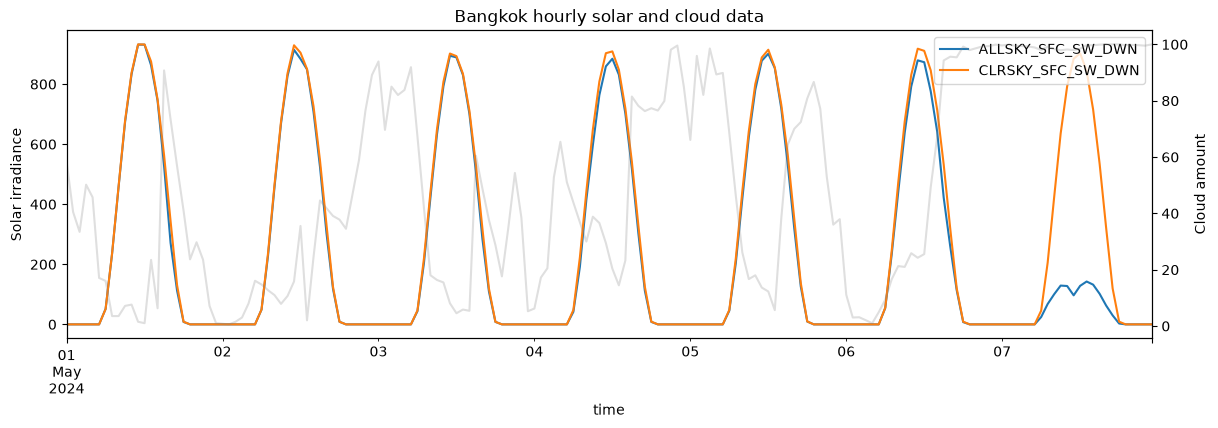

In [3]:
display(raw.describe().T.round(3))
print("missing values:")
display(raw.isna().sum().to_frame("missing"))

sample = raw.loc["2024-05-01":"2024-05-07", ["ALLSKY_SFC_SW_DWN", "CLRSKY_SFC_SW_DWN", "CLOUD_AMT"]]
fig, ax1 = plt.subplots(figsize=(14, 4))
sample[["ALLSKY_SFC_SW_DWN", "CLRSKY_SFC_SW_DWN"]].plot(ax=ax1)
ax1.set_ylabel("Solar irradiance")
ax2 = ax1.twinx()
sample.CLOUD_AMT.plot(ax=ax2, color="gray", alpha=.25)
ax2.set_ylabel("Cloud amount")
plt.title("Bangkok hourly solar and cloud data")
plt.show()

In [4]:
data = raw.copy()
data = data.ffill(limit=3)
for column in data.columns:
    data[column] = data[column].fillna(data.loc[data.index.year <= 2022, column].median())

hour = data.index.hour.to_numpy()
day = data.index.dayofyear.to_numpy()
gamma = 2 * np.pi * (day - 1 + (hour - 12) / 24) / 365.25
declination = (0.006918 - 0.399912 * np.cos(gamma) + 0.070257 * np.sin(gamma) - 0.006758 * np.cos(2 * gamma) + 0.000907 * np.sin(2 * gamma) - 0.002697 * np.cos(3 * gamma) + 0.00148 * np.sin(3 * gamma))
equation = 229.18 * (0.000075 + 0.001868 * np.cos(gamma) - 0.032077 * np.sin(gamma) - 0.014615 * np.cos(2 * gamma) - 0.040849 * np.sin(2 * gamma))
latitude = np.deg2rad(13.7563)
solar_minutes = hour * 60 + equation + 4 * (100.5018 - 105.0)
hour_angle = np.deg2rad(solar_minutes / 4 - 180)
cos_zenith = np.sin(latitude) * np.sin(declination) + np.cos(latitude) * np.cos(declination) * np.cos(hour_angle)

data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
data["day_sin"] = np.sin(2 * np.pi * day / 365.25)
data["day_cos"] = np.cos(2 * np.pi * day / 365.25)
data["declination"] = declination
data["cos_zenith"] = np.clip(cos_zenith, 0, None)
data["daylight"] = (cos_zenith > 0).astype(float)

next_hour = (hour + 1) % 24
next_day = day + (hour == 23)
next_gamma = 2 * np.pi * (next_day - 1 + (next_hour - 12) / 24) / 365.25
next_declination = (0.006918 - 0.399912 * np.cos(next_gamma) + 0.070257 * np.sin(next_gamma) - 0.006758 * np.cos(2 * next_gamma) + 0.000907 * np.sin(2 * next_gamma) - 0.002697 * np.cos(3 * next_gamma) + 0.00148 * np.sin(3 * next_gamma))
next_equation = 229.18 * (0.000075 + 0.001868 * np.cos(next_gamma) - 0.032077 * np.sin(next_gamma) - 0.014615 * np.cos(2 * next_gamma) - 0.040849 * np.sin(2 * next_gamma))
next_minutes = next_hour * 60 + next_equation + 4 * (100.5018 - 105.0)
next_angle = np.deg2rad(next_minutes / 4 - 180)
next_cos_zenith = np.sin(latitude) * np.sin(next_declination) + np.cos(latitude) * np.cos(next_declination) * np.cos(next_angle)

data["next_hour_sin"] = np.sin(2 * np.pi * next_hour / 24)
data["next_hour_cos"] = np.cos(2 * np.pi * next_hour / 24)
data["next_cos_zenith"] = np.clip(next_cos_zenith, 0, None)

data["temp_dew_spread"] = data.T2M - data.T2MDEW
wind_rad = np.deg2rad(data.WD10M)
data["wind_u"] = data.WS10M * np.sin(wind_rad)
data["wind_v"] = data.WS10M * np.cos(wind_rad)
data["clearness_index"] = (data.ALLSKY_SFC_SW_DWN / data.CLRSKY_SFC_SW_DWN.clip(lower=20)).clip(0, 2).fillna(0)

for lag in [1, 2, 3, 24, 48, 168]:
    data[f"ghi_lag_{lag}"] = data.ALLSKY_SFC_SW_DWN.shift(lag)
for window in [3, 6, 24, 168]:
    past = data.ALLSKY_SFC_SW_DWN.shift(1).rolling(window)
    data[f"ghi_mean_{window}"] = past.mean()
    data[f"ghi_std_{window}"] = past.std()
data["ghi_ramp_1"] = data.ALLSKY_SFC_SW_DWN.diff(1)
data["ghi_ramp_24"] = data.ALLSKY_SFC_SW_DWN.diff(24)

data["target"] = data.ALLSKY_SFC_SW_DWN.shift(-1)
data["target_time"] = data.index + pd.Timedelta(hours=1)
data = data.dropna()

print("engineered shape:", data.shape)
print("features created:", len(data.columns) - len(raw.columns) - 2)

engineered shape: (52439, 42)
features created: 30


In [5]:
feature_cols = [c for c in data.columns if c not in ["target", "target_time", "WD10M"]]
train_mask = data.target_time.dt.year <= 2022
val_mask = data.target_time.dt.year == 2023
test_mask = data.target_time.dt.year == 2024
private_test_labels = data.loc[test_mask, "target"].to_numpy(np.float32)

export_data = data.reset_index(names="timestamp")
train_export = export_data.loc[train_mask.to_numpy(), ["timestamp", "target_time"] + feature_cols + ["target"]].copy()
validation_export = export_data.loc[val_mask.to_numpy(), ["timestamp", "target_time"] + feature_cols + ["target"]].copy()
test_export = export_data.loc[test_mask.to_numpy(), ["timestamp", "target_time"] + feature_cols].copy()
train_export.insert(0, "id", np.arange(len(train_export)))
validation_export.insert(0, "id", np.arange(len(validation_export)))
test_export.insert(0, "id", np.arange(len(test_export)))

public_dir = data_dir / "public"
public_dir.mkdir(exist_ok=True)
train_export.to_csv(public_dir / "train.csv", index=False)
validation_export.to_csv(public_dir / "validation.csv", index=False)
test_export.to_csv(public_dir / "test.csv", index=False)

train_table = pd.read_csv(public_dir / "train.csv", parse_dates=["timestamp", "target_time"])
validation_table = pd.read_csv(public_dir / "validation.csv", parse_dates=["timestamp", "target_time"])
test_table = pd.read_csv(public_dir / "test.csv", parse_dates=["timestamp", "target_time"])
public_all = pd.concat([train_table, validation_table, test_table], ignore_index=True, sort=False)

scaler = StandardScaler().fit(train_table[feature_cols])
features = scaler.transform(public_all[feature_cols]).astype(np.float32)
target = public_all.target.to_numpy(np.float32)

LOOKBACK = 48
train_end = len(train_table)
validation_end = train_end + len(validation_table)
valid_indices = np.arange(LOOKBACK - 1, len(public_all))
train_indices = valid_indices[valid_indices < train_end]
val_indices = valid_indices[(valid_indices >= train_end) & (valid_indices < validation_end)]
test_indices = valid_indices[valid_indices >= validation_end]

print("public files:", sorted(path.name for path in public_dir.iterdir()))
print("train labeled:", train_table.shape, "target" in train_table.columns)
print("validation labeled:", validation_table.shape, "target" in validation_table.columns)
print("test unlabeled:", test_table.shape, "target" in test_table.columns)
print("features:", len(feature_cols))
print("windows:", len(train_indices), len(val_indices), len(test_indices))
print("periods:", public_all.target_time.iloc[train_indices].min(), public_all.target_time.iloc[test_indices].max())

public files: ['test.csv', 'train.csv', 'validation.csv']
train labeled: (34895, 43) True
validation labeled: (8760, 43) True
test unlabeled: (8784, 42) False
features: 39
windows: 34848 8760 8784
periods: 2019-01-10 00:00:00 2024-12-31 23:00:00


In [6]:
class SolarDataset(Dataset):
    def __init__(self, indices, labeled=True):
        self.indices = np.asarray(indices)
        self.labeled = labeled

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        end = self.indices[i]
        x = torch.from_numpy(features[end - LOOKBACK + 1:end + 1].T.copy())
        if self.labeled:
            return x, torch.tensor(target[end], dtype=torch.float32)
        return x

train_loader = DataLoader(SolarDataset(train_indices), batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(SolarDataset(val_indices), batch_size=512, shuffle=False, num_workers=0)
test_loader = DataLoader(SolarDataset(test_indices, labeled=False), batch_size=512, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), tuple(yb.shape))
print("target range:", yb.min().item(), yb.max().item())

batch: (256, 39, 48) (256,)
target range: 0.0 948.8300170898438


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, dilation, dropout=0.10):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        z = self.dropout(F.silu(self.norm1(self.conv1(x))))
        z = self.norm2(self.conv2(z))
        return F.silu(x + z)

class SolarTCN(nn.Module):
    def __init__(self, inputs):
        super().__init__()
        self.input = nn.Conv1d(inputs, 64, 1)
        self.blocks = nn.Sequential(*[ResidualBlock(64, d) for d in [1, 2, 4, 8]])
        self.head = nn.Sequential(nn.Linear(64, 64), nn.SiLU(), nn.Dropout(.10), nn.Linear(64, 1))

    def forward(self, x):
        z = self.blocks(self.input(x))
        return self.head(z[:, :, -1]).squeeze(1)

model = SolarTCN(len(feature_cols)).to(device)
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))
print("forward:", tuple(model(xb[:4].to(device)).shape))

SolarTCN(
  (input): Conv1d(39, 64, kernel_size=(1,), stride=(1,))
  (blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): ResidualBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
 

In [8]:
target_mean = float(target[train_indices].mean())
target_std = float(target[train_indices].std())
optimizer = torch.optim.AdamW(model.parameters(), lr=1.5e-3, weight_decay=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=.5, patience=2)

history = []
best = float("inf")
best_state = None
patience = 0

for epoch in range(1, 21):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred_z = model(x)
        y_z = (y - target_mean) / target_std
        daylight_weight = 0.35 + 0.65 * (y > 20).float()
        loss = (F.smooth_l1_loss(pred_z, y_z, reduction="none", beta=.20) * daylight_weight).mean()
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        running += loss.item() * len(y)

    model.eval()
    vp, vt = [], []
    with torch.no_grad():
        for x, y in val_loader:
            pred = (model(x.to(device)).cpu() * target_std + target_mean).clamp_min(0)
            vp.append(pred)
            vt.append(y)
    vp = torch.cat(vp).numpy()
    vt = torch.cat(vt).numpy()
    daylight = vt > 20
    val_mae = mean_absolute_error(vt[daylight], vp[daylight])
    train_loss = running / len(train_loader.dataset)
    history.append((epoch, train_loss, val_mae))
    scheduler.step(val_mae)

    if val_mae < best - .2:
        best = val_mae
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience = 0
    else:
        patience += 1

    print(f"epoch={epoch:02d} loss={train_loss:.4f} daylight_val_mae={val_mae:.2f} lr={optimizer.param_groups[0]['lr']:.1e}")
    if patience >= 5 and epoch >= 10:
        break

model.load_state_dict(best_state)
print("best daylight validation MAE:", round(best, 3))

epoch=01 loss=0.0494 daylight_val_mae=26.99 lr=1.5e-03


epoch=02 loss=0.0267 daylight_val_mae=26.91 lr=1.5e-03


epoch=03 loss=0.0235 daylight_val_mae=22.94 lr=1.5e-03


epoch=04 loss=0.0230 daylight_val_mae=24.81 lr=1.5e-03


epoch=05 loss=0.0221 daylight_val_mae=23.81 lr=1.5e-03


...

epoch=08 loss=0.0197 daylight_val_mae=22.46 lr=7.5e-04


epoch=09 loss=0.0194 daylight_val_mae=22.93 lr=7.5e-04


epoch=10 loss=0.0201 daylight_val_mae=22.77 lr=3.8e-04


epoch=11 loss=0.0191 daylight_val_mae=21.65 lr=3.8e-04


epoch=12 loss=0.0191 daylight_val_mae=21.68 lr=3.8e-04
best daylight validation MAE: 21.655


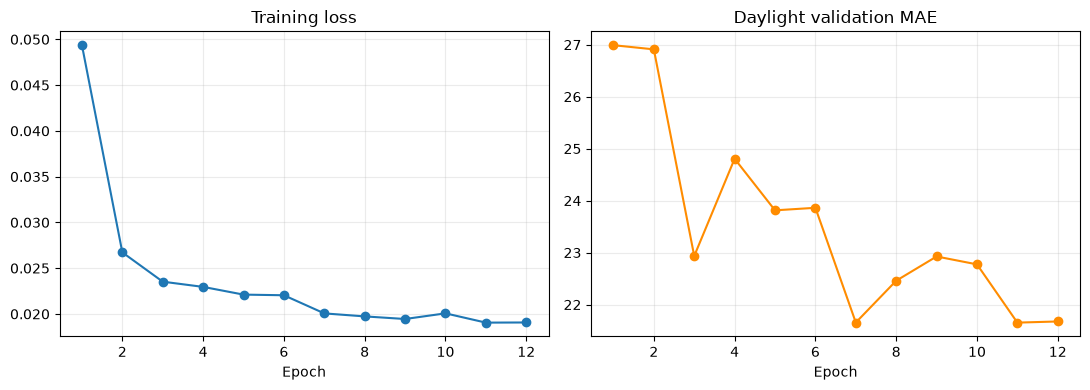

In [9]:
hist = pd.DataFrame(history, columns=["epoch", "train_loss", "daylight_validation_mae"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist.epoch, hist.train_loss, marker="o")
axes[0].set_title("Training loss")
axes[1].plot(hist.epoch, hist.daylight_validation_mae, marker="o", color="darkorange")
axes[1].set_title("Daylight validation MAE")
for ax in axes:
    ax.grid(alpha=.25)
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

In [10]:
model.eval()
pred_list = []
with torch.no_grad():
    for x in test_loader:
        pred_list.append((model(x.to(device)).cpu() * target_std + target_mean).clamp_min(0))
pred = torch.cat(pred_list).numpy()
true = private_test_labels.copy()
times = test_table.target_time.reset_index(drop=True)
current_ghi = test_table.ALLSKY_SFC_SW_DWN.to_numpy()
daylight = true > 20

def report(name, y, p):
    return {"model": name, "MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** .5, "R2": r2_score(y, p)}

report_df = pd.DataFrame([
    report("Persistence all", true, current_ghi),
    report("TCN all", true, pred),
    report("Persistence daylight", true[daylight], current_ghi[daylight]),
    report("TCN daylight", true[daylight], pred[daylight])
])
display(report_df.round(4))

,model,MAE,RMSE,R2
0,Persistence all,64.9650,100.9913,0.8799
1,TCN all,11.2660,25.0921,0.9926
2,Persistence daylight,127.6486,143.4550,0.7094
3,TCN daylight,21.8962,36.0785,0.9816


In [11]:
submission = pd.DataFrame({"id": np.arange(len(pred)), "predicted_ghi": np.clip(pred, 0, None)})
submission.to_csv("submission_solar.csv", index=False)

print("public test columns:", test_table.columns.tolist())
print("target present:", "target" in test_table.columns)
print("submission:", submission.shape)
submission.head(10)

public test columns: ['id', 'timestamp', 'target_time', 'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'T2MDEW', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'CLOUD_AMT', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'declination', 'cos_zenith', 'daylight', 'next_hour_sin', 'next_hour_cos', 'next_cos_zenith', 'temp_dew_spread', 'wind_u', 'wind_v', 'clearness_index', 'ghi_lag_1', 'ghi_lag_2', 'ghi_lag_3', 'ghi_lag_24', 'ghi_lag_48', 'ghi_lag_168', 'ghi_mean_3', 'ghi_std_3', 'ghi_mean_6', 'ghi_std_6', 'ghi_mean_24', 'ghi_std_24', 'ghi_mean_168', 'ghi_std_168', 'ghi_ramp_1', 'ghi_ramp_24']
target present: False
submission: (8784, 2)


,id,predicted_ghi
0,0,0.000000
1,1,0.162064
2,2,1.201309
3,3,2.141754
4,4,0.000000
5,5,0.000000
6,6,12.663162
7,7,97.314163
8,8,329.624603
9,9,539.261841


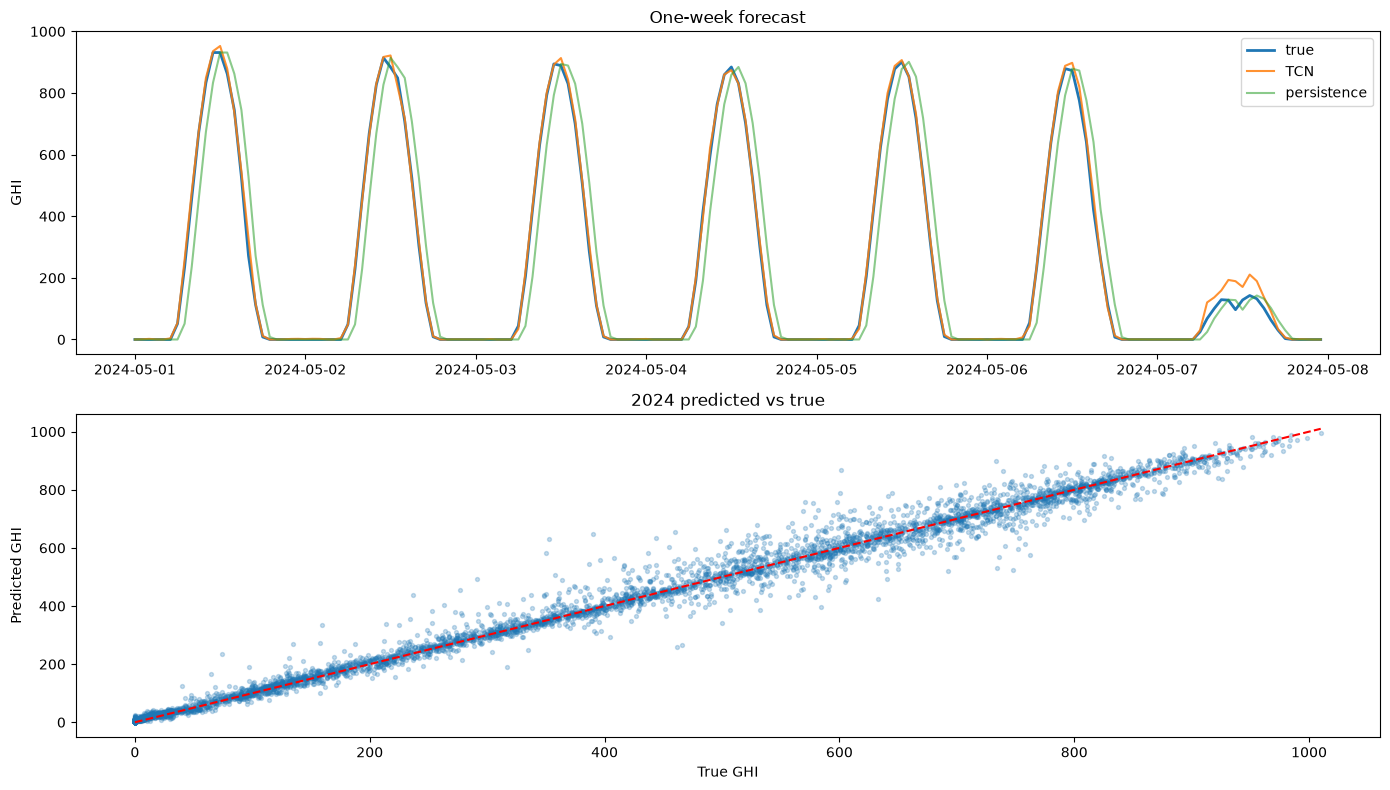

In [12]:
result = pd.DataFrame({"time": times, "true": true, "prediction": pred, "persistence": current_ghi})
result["absolute_error"] = np.abs(result.true - result.prediction)
week = result[(result.time >= "2024-05-01") & (result.time < "2024-05-08")]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(week.time, week.true, label="true", linewidth=2)
axes[0].plot(week.time, week.prediction, label="TCN", alpha=.85)
axes[0].plot(week.time, week.persistence, label="persistence", alpha=.55)
axes[0].legend()
axes[0].set_title("One-week forecast")
axes[0].set_ylabel("GHI")
axes[1].scatter(result.true, result.prediction, s=8, alpha=.25)
limits = [0, max(result.true.max(), result.prediction.max())]
axes[1].plot(limits, limits, "r--")
axes[1].set_xlabel("True GHI")
axes[1].set_ylabel("Predicted GHI")
axes[1].set_title("2024 predicted vs true")
plt.tight_layout()
plt.show()

In [13]:
result["hour"] = result.time.dt.hour
hourly = result.groupby("hour").agg(n=("absolute_error", "size"), mae=("absolute_error", "mean"), true_mean=("true", "mean"), predicted_mean=("prediction", "mean"))
display(hourly.round(2))
result.nlargest(12, "absolute_error")

,n,mae,true_mean,predicted_mean
hour,,,,
0,366,0.630000,0.000000,0.630000
1,366,0.730000,0.000000,0.730000
2,366,1.030000,0.000000,1.030000
3,366,0.750000,0.000000,0.750000
4,366,0.450000,0.000000,0.450000
5,366,2.620000,0.000000,2.620000
6,366,7.980000,22.309999,25.980000
7,366,11.880000,147.139999,147.440002
8,366,10.590000,330.839996,330.380005


,time,true,prediction,persistence,absolute_error,hour
6948,2024-10-16 12:00:00,352.269989,631.316406,622.75,279.046417,12
1452,2024-03-01 12:00:00,601.599976,868.483093,838.22,266.883118,12
5147,2024-08-02 11:00:00,389.880005,647.900330,560.20,258.020325,11
4236,2024-06-25 12:00:00,349.920013,582.260986,586.75,232.340973,12
1453,2024-03-01 13:00:00,747.650024,525.161011,601.60,222.489014,13
5917,2024-09-03 13:00:00,632.599976,424.704773,397.73,207.895203,13
3468,2024-05-24 12:00:00,734.549988,529.207031,516.78,205.342957,12
4596,2024-07-10 12:00:00,461.730011,258.782562,224.82,202.947449,12
4954,2024-07-25 10:00:00,290.980011,493.673279,370.92,202.693268,10
4259,2024-06-26 11:00:00,465.619995,264.550354,253.23,201.069641,11
